In [1]:
print("Hoangha")

Hoangha


## Preparing a dataset for instruction  fine-tuning

In [2]:
import json
import os
import urllib.request


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")

        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    data = json.loads(text_data)
    return data


file_path = "instruction-data.json"

url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)

print("Number of entries:", len(data))

Number of entries: 1100


In [3]:
print("Example entry: \n", data[50])

Example entry: 
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [4]:
print("Another example entry:\n", data[999])


Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [5]:
def format_input(entry): 
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request. "
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )

    return instruction_text + input_text

In [6]:
model_input = format_input(data[50])
desired_response =  f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [7]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


### Split dataset

In [8]:
train_portion = int(len(data)*0.85)
test_portion = int(len(data)*0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion: train_portion+test_portion]
val_data = data[train_portion+test_portion :]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## organizing data into training batches

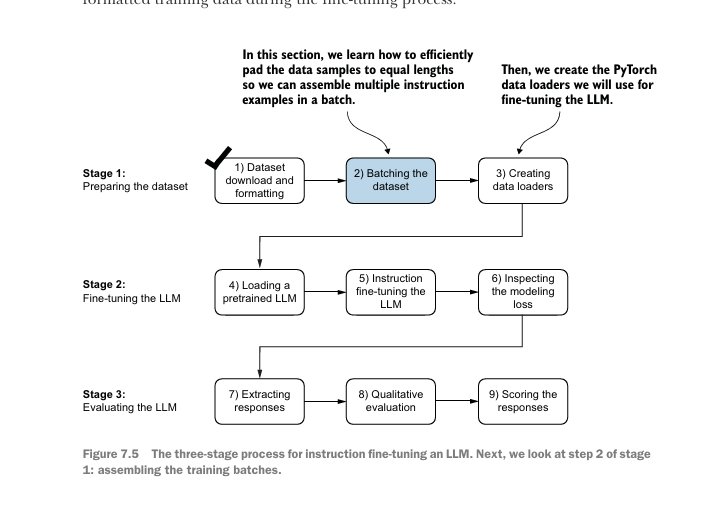

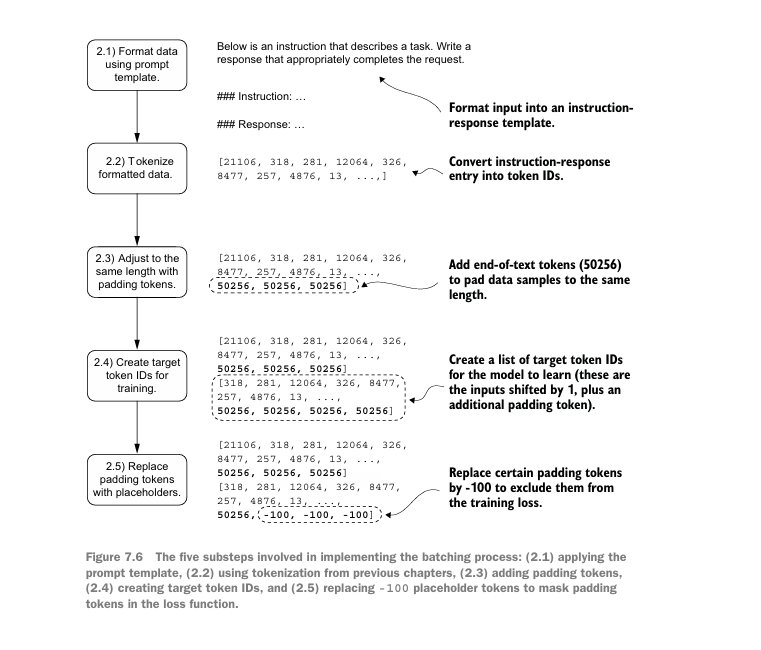

In [9]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset): 
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data: 
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    def __getitem__(self,index): 
        return self.encoded_texts[index]
    def __len__(self): 
        return len(self.data)

In [10]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


### Add padding

In [11]:
def custom_collate_draft_1(
    batch, pad_token_id = 50256, 
    device = "cpu"
): 
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []
    for item in batch: 
        new_item = item.copy()
        new_item +=[pad_token_id]
        padded = (
            new_item + [pad_token_id]*(batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [12]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [13]:
def custom_collate_draft_2(
    batch, pad_token_id = 50256, device = "cpu"
): 
    batch_max_length=max(len(item)+1 for item in batch)
    inputs_lst , targets_lst = [],[]
    for item in batch: 
        new_item = item.copy()
        new_item +=[pad_token_id]
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


### Replace special token to -100
- Loss for meanningfull token , not forall

In [14]:
def custom_collate_fn(
    batch, pad_token_id = 50256, ignore_index = -100, allowed_max_length = None, device = "cpu"
): 
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [],[]
    for item in batch: 
        new_item = item.copy()
        new_item+=[pad_token_id]

        padded = (
            new_item + [pad_token_id]* (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        mask = targets == pad_token_id
        indicies = torch.nonzero(mask).squeeze()
        if indicies.numel() > 1 : 
            targets[indicies[1:]] = ignore_index
        if allowed_max_length is not None: 
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [15]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


### why -100

In [16]:
logits_1 = torch.tensor(
    [[-1.0, 1.0], 
    [-0.5, 1.5]]
)
targets_1 = torch.tensor([0,1])
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [17]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]     
)

targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [18]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)


tensor(1.1269)
loss_1 == loss_3: tensor(True)


### Creating dataloader

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():  
#     device = torch.device("mps")"      
print("Device:", device)

Device: cuda


In [20]:
from functools import partial
customized_collate_fn = partial(
    custom_collate_fn, 
    device = device, 
    allowed_max_length = 1024
)

In [21]:
from torch.utils.data import DataLoader

num_workers = 0 
batch_size = 8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset, 
    batch_size = batch_size, 
    collate_fn = customized_collate_fn,
    shuffle = True, 
    drop_last = True, 
    num_workers = num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [22]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 69]) torch.

## Download model 

In [23]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [24]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True,         # Query-key-value bias
    "emb_dim":768
}

In [31]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2-medium"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

model.eval()

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [32]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [33]:
text = "Hoang ha is"

inputs = tokenizer(text, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=30
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Hoang ha is a very good player, but he's not a great player. He's not a great player. He's not a great player. He's not


In [34]:
inputs = tokenizer(input_text, return_tensors="pt")
outputs = model.generate(
    **inputs,
    max_new_tokens=35
)

generated_text = (tokenizer.decode(outputs[0], skip_special_tokens=True))
print(generated_text)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [35]:
response_text = generated_text[len(input_text):].strip()
print(response_text)


### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## Fine tuning the LLM 

In [40]:
def calc_loss_batch(input_batch, target_batch, model, device): 
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    outputs = model(input_batch)
    logits = outputs.logits

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss

In [41]:
def calc_loss_loader(data_loader, model, device, num_batches=None): 
    total_loss = 0

    if len(data_loader) == 0: 
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else: 
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader): 
        if i < num_batches: 
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

In [38]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer): 
    train_losses, val_losses, track_tokens_seen =[],[],[]
    tokens_seen, global_step =0,-1
    for epoch in range(num_epochs): 
        model.train()
        for input_batch,target_batch in train_loader: 
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch,target_batch,model,device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step+=1
            if global_step % eval_freq ==0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader,val_loader, device,eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                          f"Train loss {train_loss:.3f}, "
                          f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model,tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter): 
    model.eval()
    with torch.no_grad(): 
        train_loss= calc_loss_loader(
            train_loader, model, device, num_batches = eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device , num_batches = eval_iter
        )
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context): 
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad(): 
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size = context_size
        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n"," "))
    model.train()

In [42]:
model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.9499627590179442
Validation loss: 3.8900279998779297


In [43]:
def generate_and_print_sample(model, tokenizer, device, start_context): 
    model.eval()

    encoded = tokenizer(
        start_context,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad(): 
        output_ids = model.generate(
            **encoded,
            max_new_tokens=50,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    response_text = decoded_text[len(start_context):].strip()

    print(response_text.replace("\n", " "))

    model.train()

In [44]:
import time

start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60

print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.652, Val loss 2.639
Ep 1 (Step 000005): Train loss 1.163, Val loss 1.100
Ep 1 (Step 000010): Train loss 0.860, Val loss 0.961
Ep 1 (Step 000015): Train loss 0.863, Val loss 0.918
Ep 1 (Step 000020): Train loss 0.799, Val loss 0.903
Ep 1 (Step 000025): Train loss 0.762, Val loss 0.872
Ep 1 (Step 000030): Train loss 0.815, Val loss 0.859
Ep 1 (Step 000035): Train loss 0.735, Val loss 0.830
Ep 1 (Step 000040): Train loss 0.701, Val loss 0.823
Ep 1 (Step 000045): Train loss 0.655, Val loss 0.816
Ep 1 (Step 000050): Train loss 0.708, Val loss 0.803
Ep 1 (Step 000055): Train loss 0.780, Val loss 0.792
Ep 1 (Step 000060): Train loss 0.740, Val loss 0.771
Ep 1 (Step 000065): Train loss 0.667, Val loss 0.752
Ep 1 (Step 000070): Train loss 0.570, Val loss 0.742
Ep 1 (Step 000075): Train loss 0.580, Val loss 0.741
Ep 1 (Step 000080): Train loss 0.641, Val loss 0.736
Ep 1 (Step 000085): Train loss 0.537, Val loss 0.728
Ep 1 (Step 000090): Train loss 0.586, Val loss

In [49]:
inputs = tokenizer(input_text, return_tensors="pt").to(device)

outputs = model.generate(
    **inputs,
    max_new_tokens=35,
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:
The meal is cooked every day by the chef.


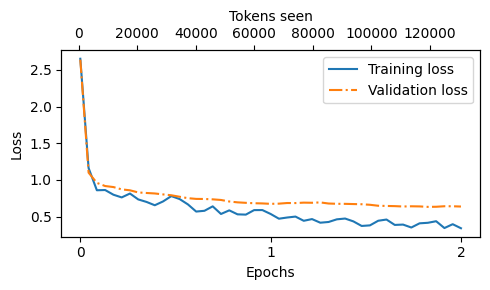

In [48]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses): 
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                  
    ax2.plot(tokens_seen, train_losses, alpha=0)    
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)